In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Define the basin states

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [3]:
# Generate seed trajectory for TPS: Madlen
# Conditions:
# --- Model ---
# eps = 0.05
# Vc = 0.2
# --- Seed trajectories ---
# v_init = -0.0087
# q_init = 1.0
# coeff_init = np.array([1.0, 0.0], dtype=complex)
# mass = 1836.15
# act_state_init = 0
# dt = 5
# max_steps = 10000000
# --- TPS setup ---
# TPS temperature = 12000K
# Sample size = 10000
# maximum trajectory length = 5000

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000000

x0 = 1.0
k = 0.1
Vc = 0.2
eps = 0.05

SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

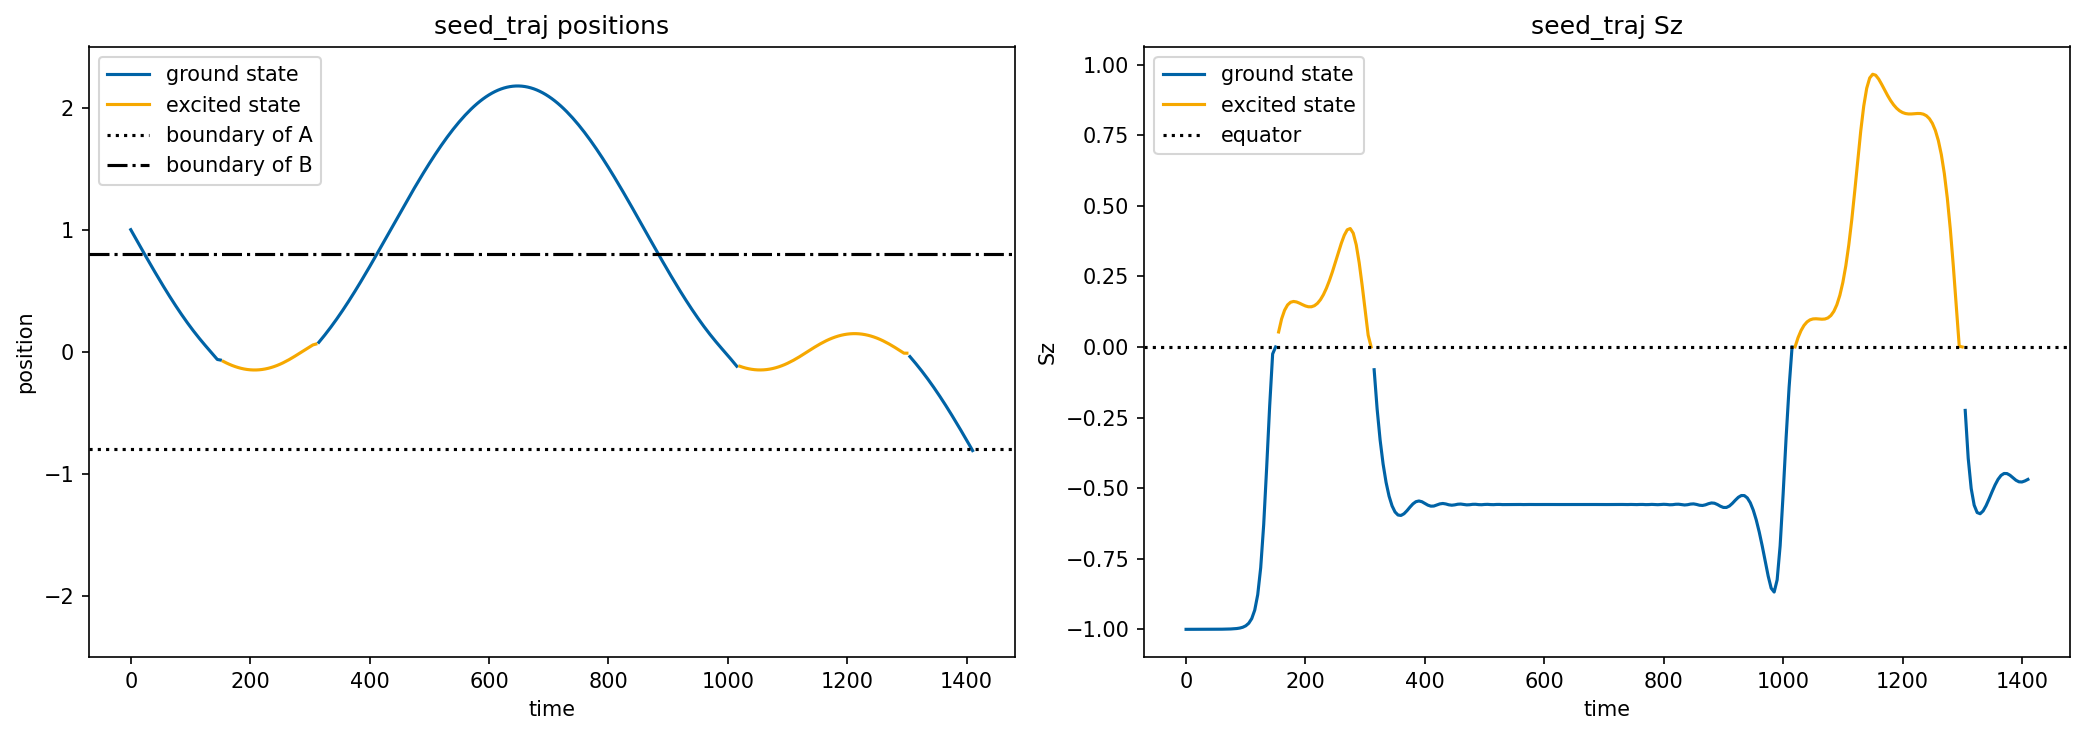

In [4]:
# PLOT SEED TRAJECTORY

labelstates = ["ground state", "excited state"]
colorstates = ["#0063A6","#F6A800","#666666"]

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

# --- Create subplots ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

# Left: Positions
axes[0].plot(np.arange(len(seed_traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
axes[0].plot(np.arange(len(seed_traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
axes[0].set_xlabel("time")
axes[0].set_ylabel("position")
axes[0].set_ylim([-2.5, 2.5])
axes[0].set_title("seed_traj positions")
axes[0].legend(loc=2)

# Right: Sz
axes[1].plot(np.arange(len(seed_traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
axes[1].plot(np.arange(len(seed_traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Sz")
axes[1].set_title("seed_traj Sz")
axes[1].legend(loc=2)

plt.tight_layout()
plt.show()

In [ ]:
# Main TPS proof of concept with the selected condition Page 1: main sequence

ensemble_size = 10000
max_traj_length = 5000

tps_selector = UniformShootingSelector(temp=12000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                             max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)

engine_builder = MASHEngine
tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate = path_sampling.MC_acceptance()

transit_times, mean_time, std_time = path_sampling.transit_time_statistics(tps_ensemble=tps_ensemble, dt=dt)
speedup = path_sampling.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble, mc_rate=MC_rate)

max_lag = 100
auto_correlation = path_sampling.compute_autocorrelation(data=transit_times, max_lag=max_lag)

mean_hops, std_hops, q_hops = path_sampling.hop_statistics(tps_ensemble=tps_ensemble)

--- TPS Iteration 0 ---
Accepted
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Rejected
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Accepted
--- TPS Iteration 5 ---
Rejected
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Rejected
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Accepted
--- TPS Iteration 13 ---
Rejected
--- TPS Iteration 14 ---
Accepted
--- TPS Iteration 15 ---
Rejected
--- TPS Iteration 16 ---
Rejected
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Accepted
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Rejected
--- TPS Iteration 28 ---
Rejected
--- TPS Iteration 29 ---

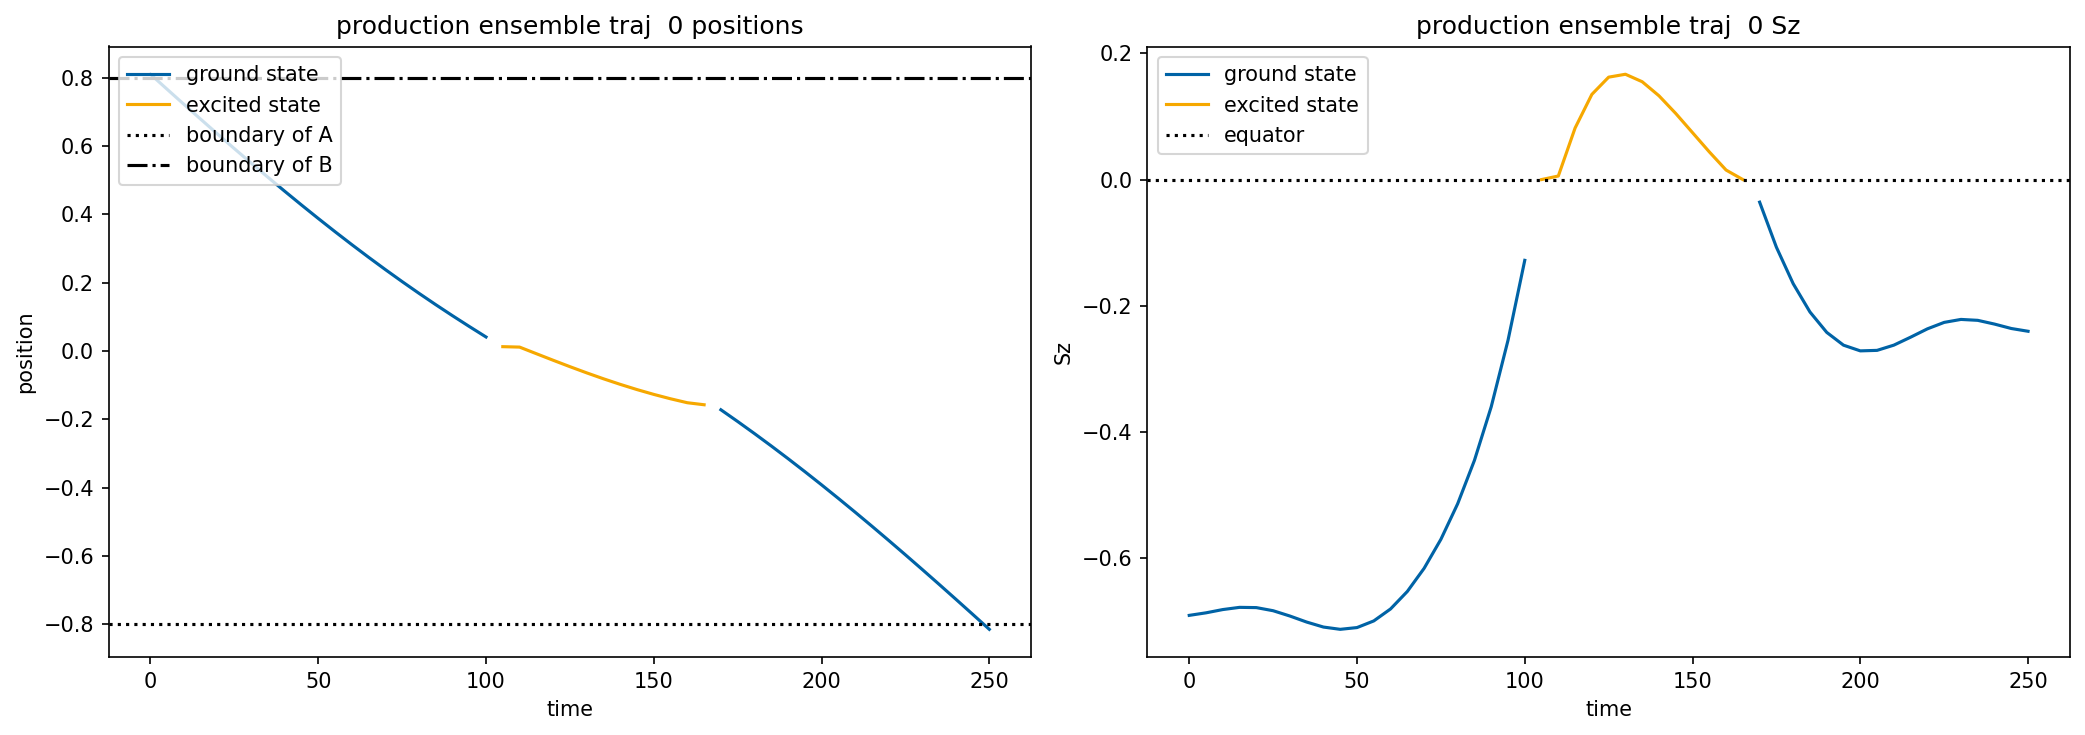

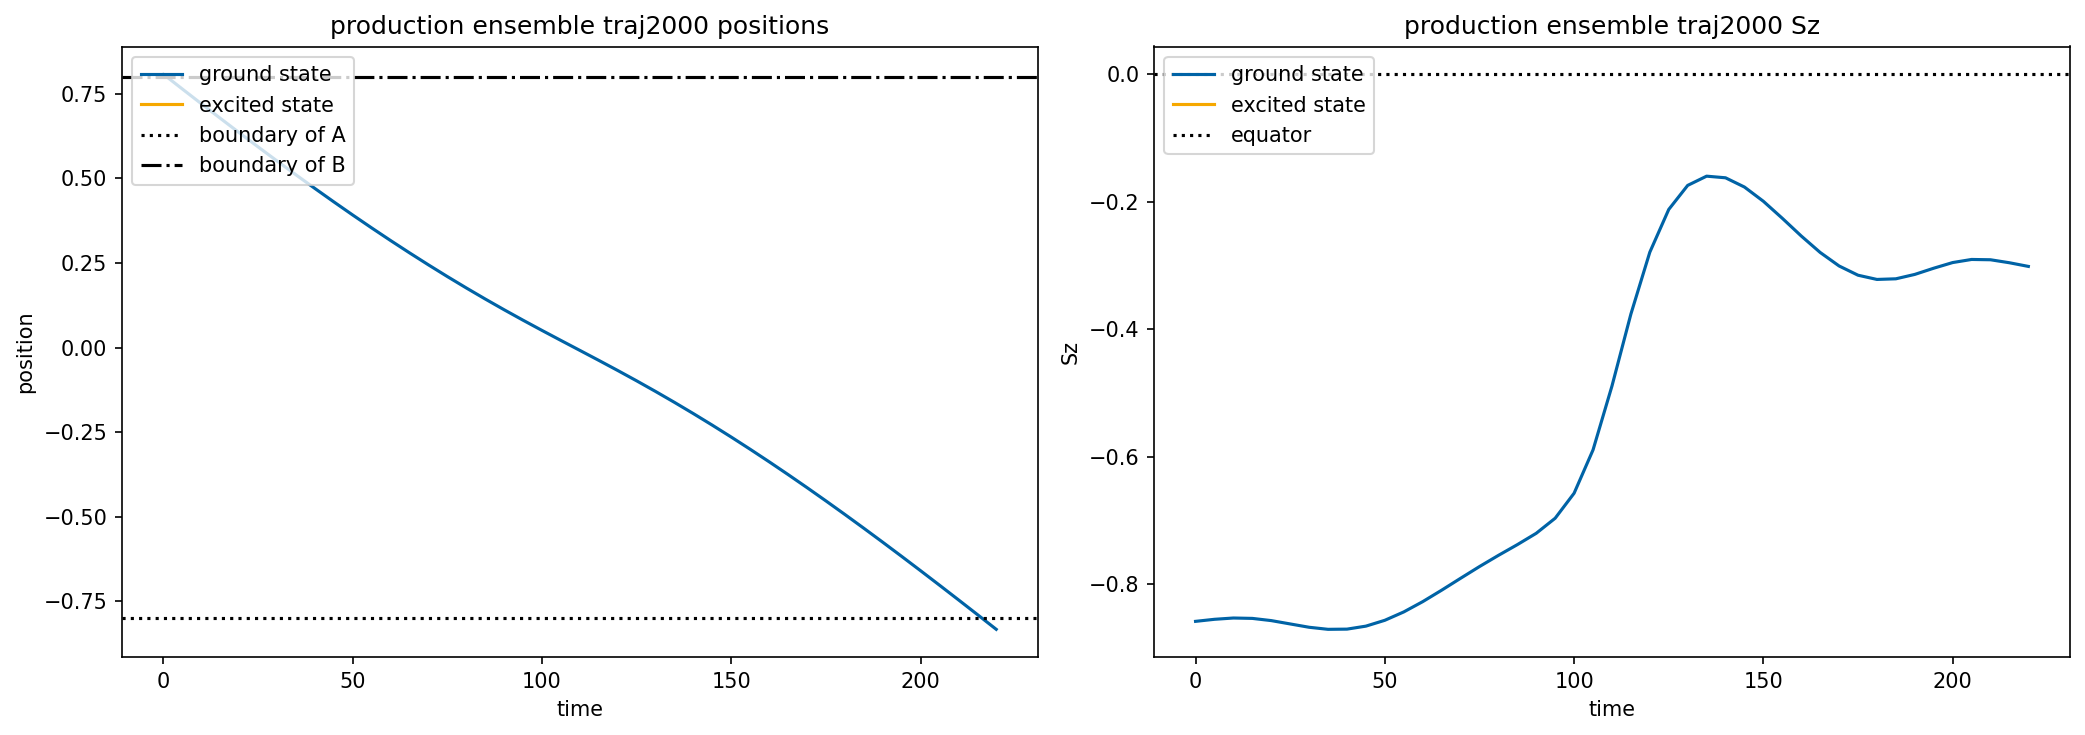

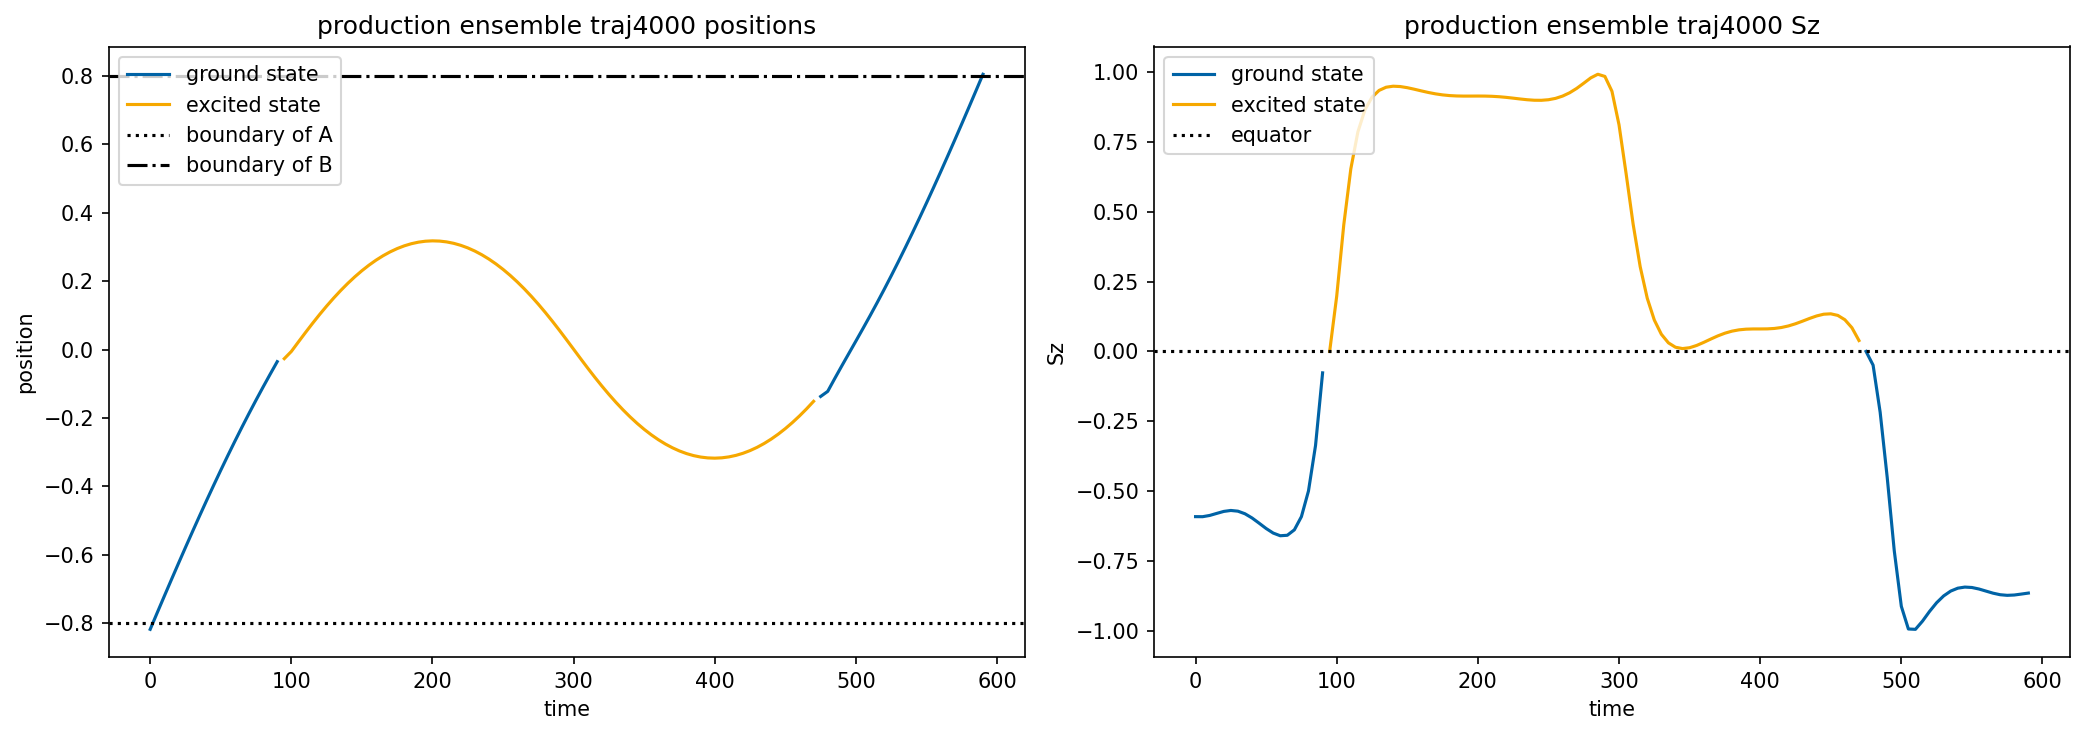

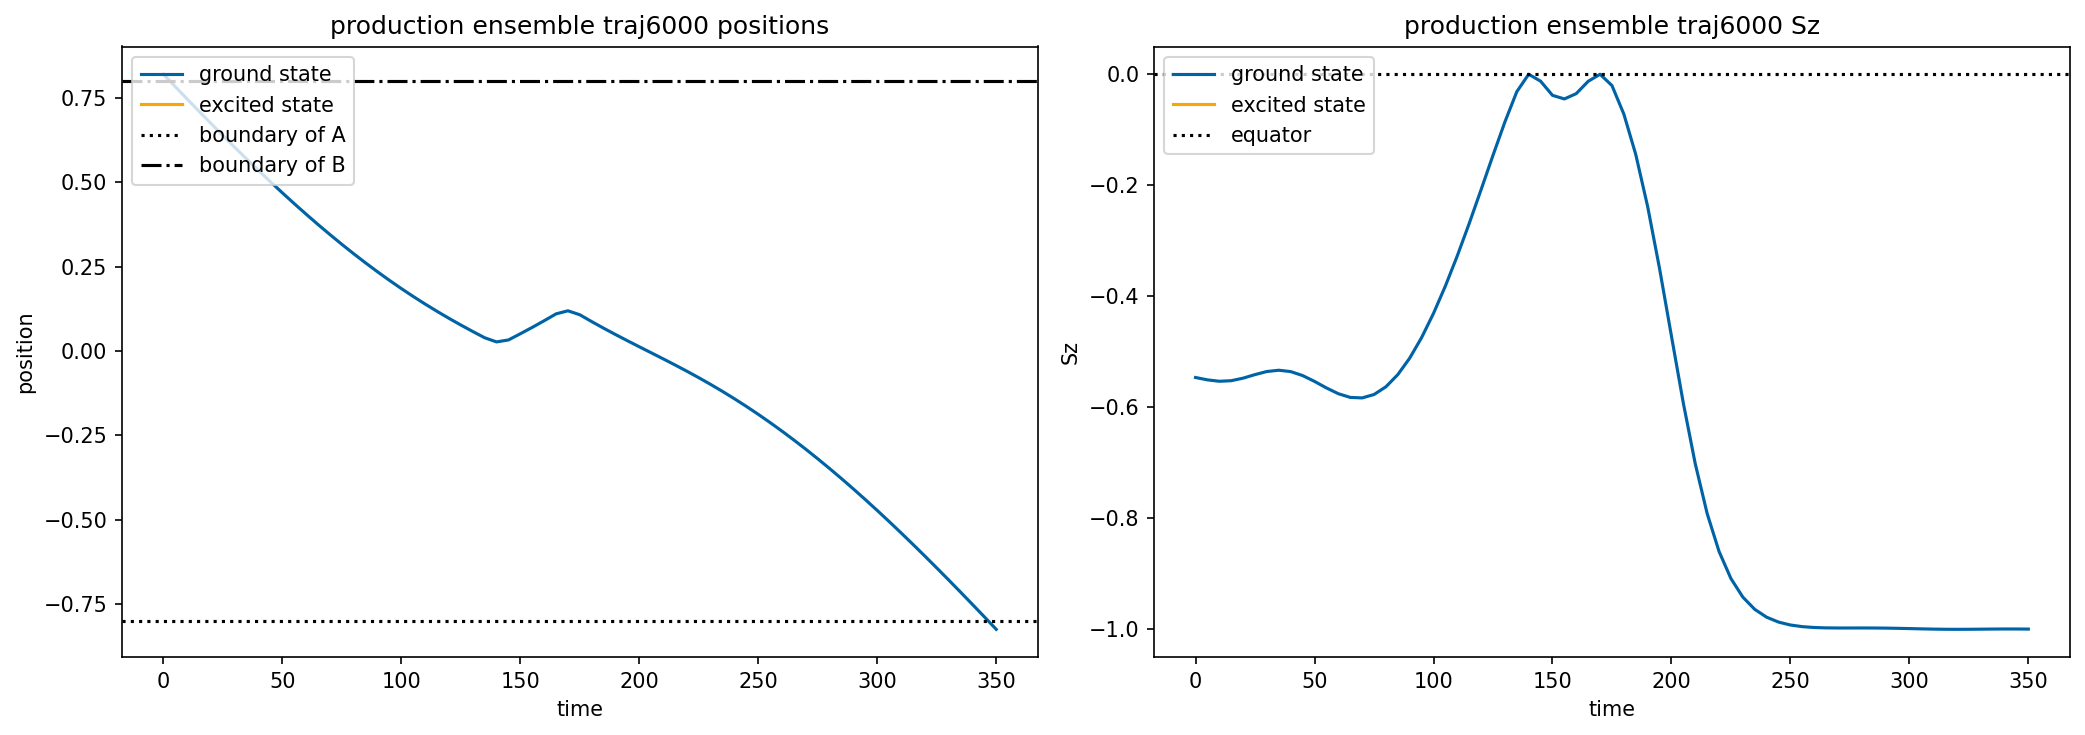

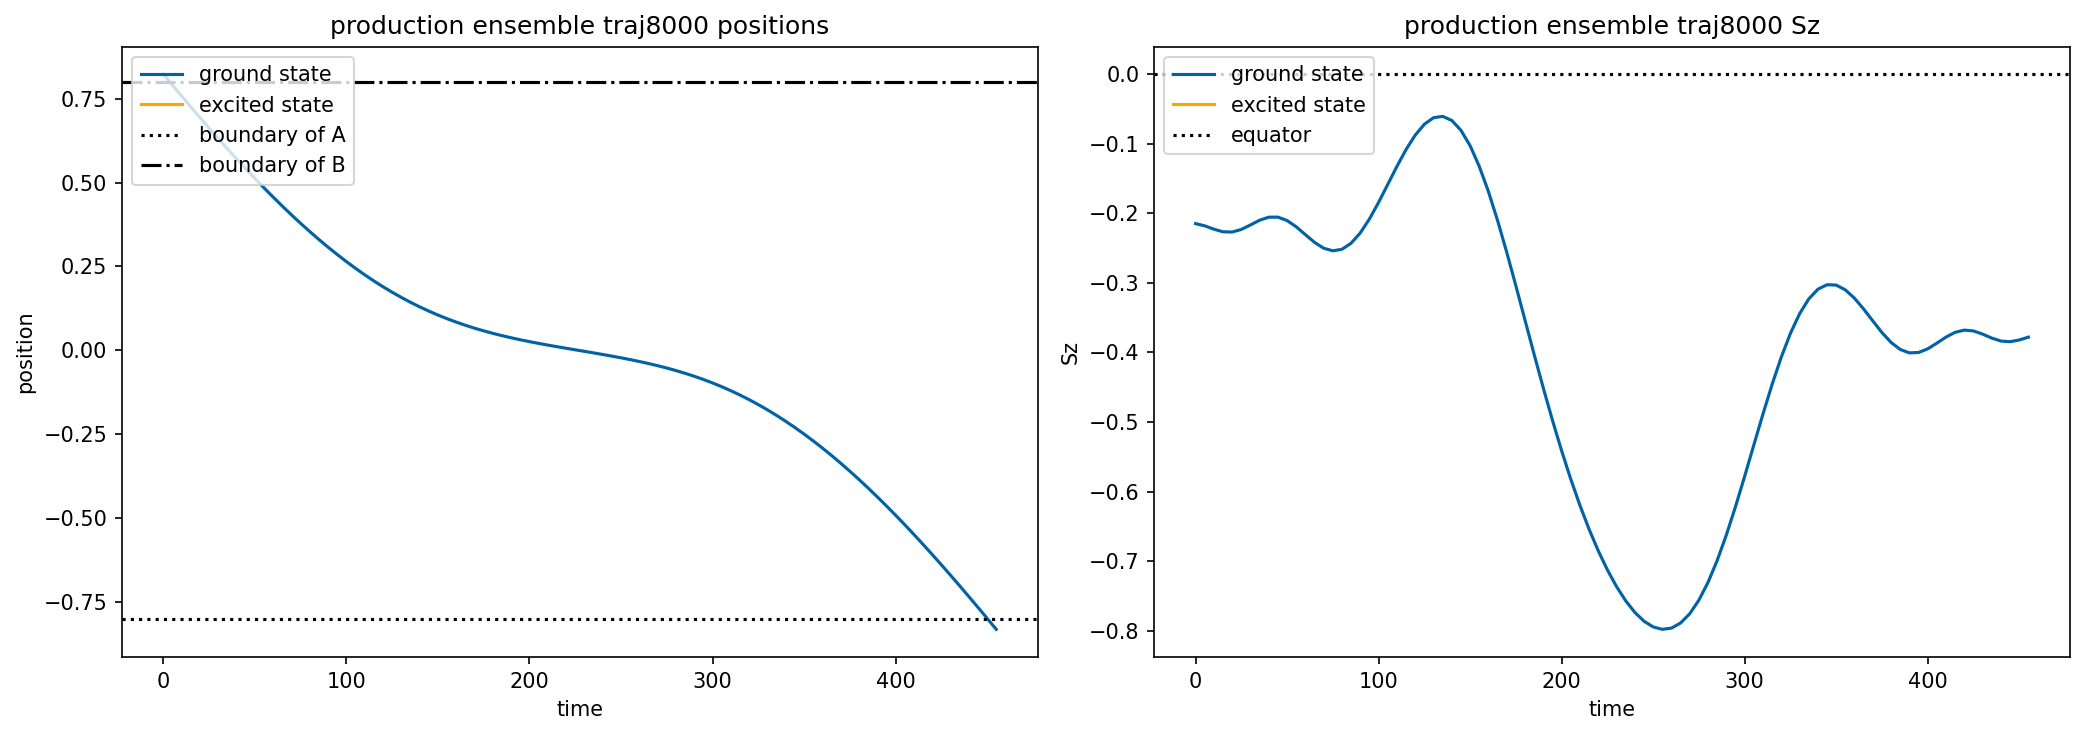

In [ ]:
# Main TPS proof of concept with the selected condition Page 2: Plot some trajectories

burn_in = 0.15
discard = int(burn_in * len(tps_ensemble))
trimmed_tps_ensemble = tps_ensemble[discard:]

for k in range(0, len(trimmed_tps_ensemble), 2000):
    traj = trimmed_tps_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    ground_state_positions = np.copy(oscillator_positions)
    ground_state_positions[active_states > 0] = np.nan
    excited_state_positions = np.copy(oscillator_positions)
    excited_state_positions[active_states != 1] = np.nan

    # --- Coefficients ---
    oscillator_coeffs = np.array([sz_from_coeff(traj[i].coefficients) for i in range(len(traj))])
    ground_state_coeffs = np.copy(oscillator_coeffs)
    ground_state_coeffs[active_states > 0] = np.nan
    excited_state_coeffs = np.copy(oscillator_coeffs)
    excited_state_coeffs[active_states != 1] = np.nan

    # --- Create subplots ---
    fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

    # Left: Positions
    axes[0].plot(np.arange(len(traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
    axes[0].plot(np.arange(len(traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
    axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
    axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("position")
    axes[0].set_title(f"production ensemble traj{k:3d} positions")
    axes[0].legend(loc=2)

    # Right: Sz
    axes[1].plot(np.arange(len(traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
    axes[1].plot(np.arange(len(traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
    axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("Sz")
    axes[1].set_title(f"production ensemble traj{k:3d} Sz")
    axes[1].legend(loc=2)

    plt.tight_layout()
    plt.show()


In [ ]:
# Main TPS proof of concept with the selected condition Page 3: number of trajectories with hop at the selected condition

traj_with_hop = 0
for k in range(0, len(trimmed_tps_ensemble)):
    traj = trimmed_tps_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    if np.any(active_states) == 1:
        traj_with_hop +=1
print(traj_with_hop)

2838


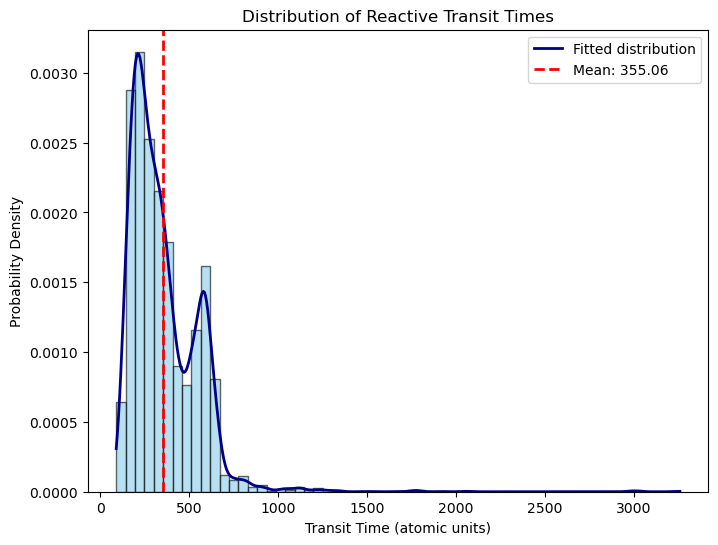

In [ ]:
# Main TPS proof of concept with the selected condition Page 4: Transition time distribution

import numpy as np
from scipy.stats import gaussian_kde
from matplotlib import pyplot as plt

# Histogram (normalize to density!)
plt.figure(figsize=(8, 6))
counts, bins, _ = plt.hist(
    transit_times,
    bins=60,
    density=True,          # IMPORTANT
    color='skyblue',
    edgecolor='black',
    alpha=0.6
)

# KDE
kde = gaussian_kde(transit_times)
x_grid = np.linspace(min(transit_times), max(transit_times), 500)
plt.plot(x_grid, kde(x_grid), color='darkblue', linewidth=2, label="Fitted distribution")

# Mean line
plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
            label=f'Mean: {mean_time:.2f}')

plt.title("Distribution of Reactive Transit Times")
plt.xlabel("Transit Time (atomic units)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

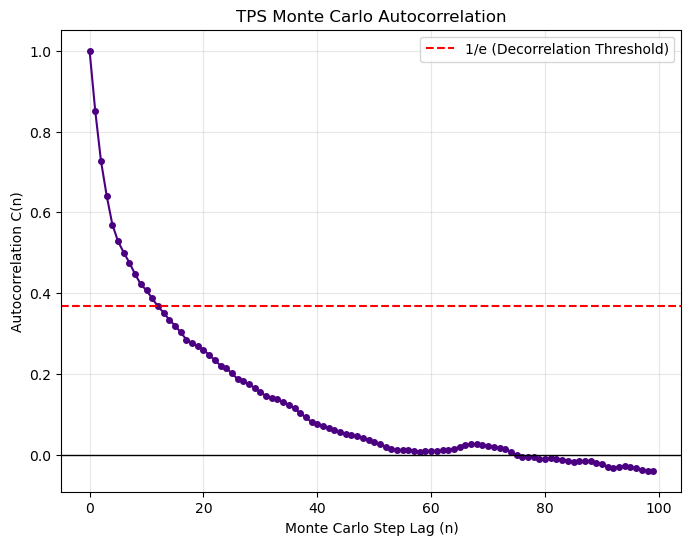

In [ ]:
# # Main TPS proof of concept with the selected condition Page 5: Decorrelation plots

max_mc_lag = max_lag
plt.figure(figsize=(8, 6))
plt.plot(range(max_mc_lag), auto_correlation, marker='o', markersize=4, linestyle='-', color='indigo')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(np.exp(-1), color='red', linestyle='dashed', label='1/e (Decorrelation Threshold)')

plt.title("TPS Monte Carlo Autocorrelation")
plt.xlabel("Monte Carlo Step Lag (n)")
plt.ylabel("Autocorrelation C(n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

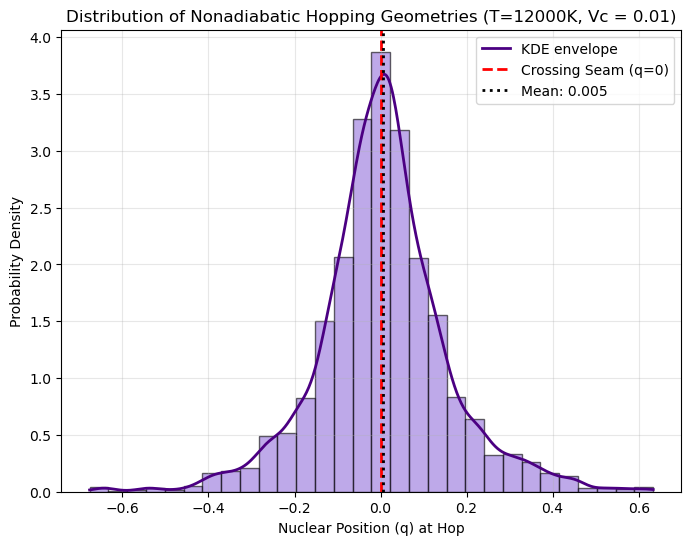

In [ ]:
# Main TPS proof of concept with the selected condition Page 6: Hopping geometry

import numpy as np
from scipy.stats import gaussian_kde
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))

# Histogram (already normalized)
plt.hist(
    q_hops,
    bins=30,
    color='mediumpurple',
    edgecolor='black',
    alpha=0.6,
    density=True
)

# --- KDE envelope ---
kde = gaussian_kde(q_hops)
x_grid = np.linspace(min(q_hops), max(q_hops), 500)
plt.plot(x_grid, kde(x_grid), color='indigo', linewidth=2, label="KDE envelope")

# Crossing seam
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2,
            label='Crossing Seam (q=0)')

# Mean hopping position
mean_q = np.mean(q_hops)
plt.axvline(mean_q, color='black', linestyle='dotted', linewidth=2,
            label=f'Mean: {mean_q:.3f}')

plt.title("Distribution of Nonadiabatic Hopping Geometries (T=12000K, Vc = 0.01)")
plt.xlabel("Nuclear Position (q) at Hop")
plt.ylabel("Probability Density")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

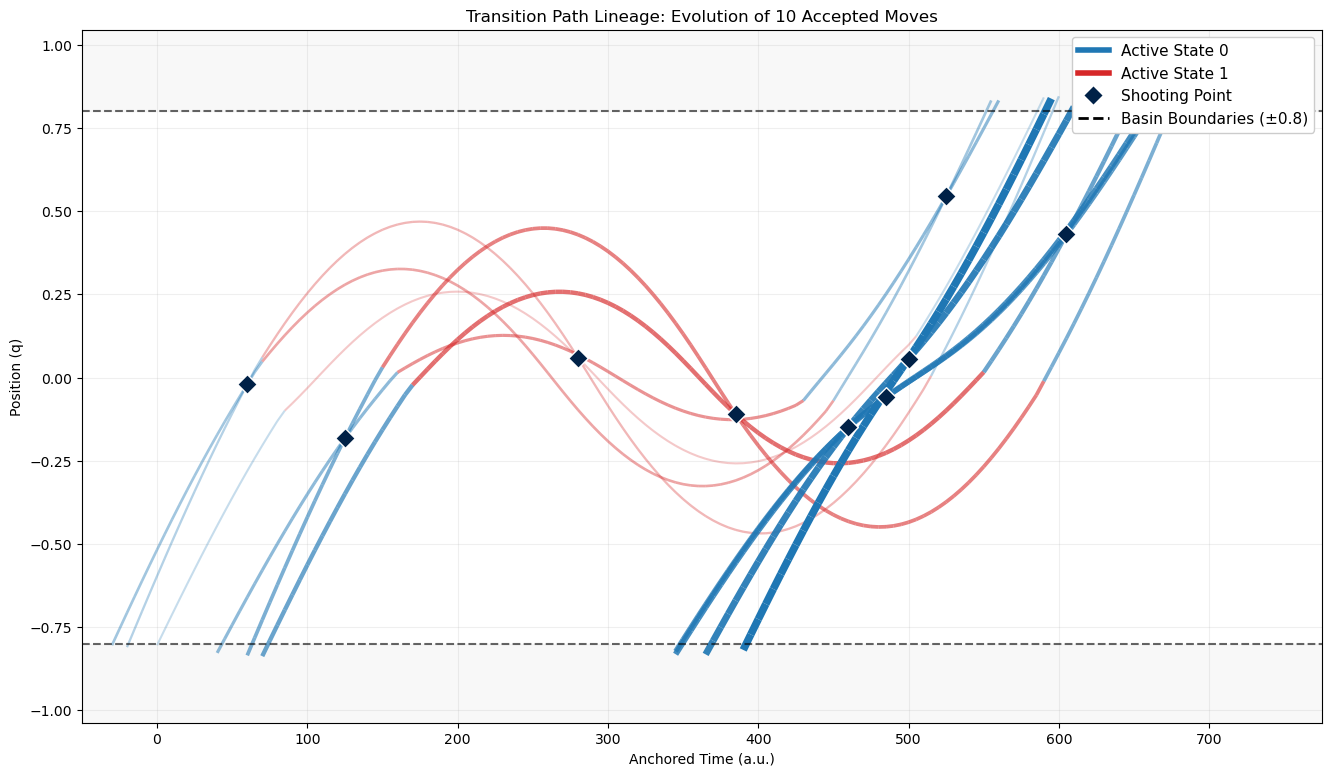

In [ ]:
# Main TPS proof of concept with the selected condition Page 7: Path lineage visualisation

from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

def visualize_tps_ensemble(ensemble, dt, max_plot=10):
    """
    Plots a superimposed transition path ensemble.
    ensemble: list of Trajectory objects from the PathSampling class.
    dt: the time step of the grid.
    max_plot: maximum number of trajectories to plot to avoid visual clutter.
    """
    plt.figure(figsize=(12, 7))
    
    # Subsample to avoid overplotting a solid block of color
    step = max(1, len(ensemble) // max_plot)
    plot_ensemble = ensemble[::step]
    
    q_min, q_max = float('inf'), float('-inf')
    
    # Define exact color hexes for a professional palette
    oxford_blue = '#002147'  # For the shooting points
    state_0_color = '#1f77b4' # Muted blue for active state 0
    state_1_color = '#d62728' # Muted red for active state 1

    for traj in plot_ensemble:
        # Filter strictly for grid points to maintain constant dt scaling
        grid_traj = [snap for snap in traj if snap.is_grid]
        if not grid_traj:
            continue
            
        times = np.arange(len(grid_traj)) * dt
        positions = [snap.positions for snap in grid_traj]
        states = [snap.active_state for snap in grid_traj]
        
        q_min = min(q_min, min(positions))
        q_max = max(q_max, max(positions))
        
        # Create line segments for multicolor plotting
        points = np.array([times, positions]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        colors = [state_0_color if state == 0 else state_1_color for state in states[:-1]]
        
        lc = LineCollection(segments, colors=colors, alpha=0.3, linewidths=1.5)
        plt.gca().add_collection(lc)
        
        # Highlight the exact shooting snapshot
        for i, snap in enumerate(grid_traj):
            if getattr(snap, 'shooting', False) is True:
                plt.scatter(times[i], positions[i], color=oxford_blue, 
                            edgecolor='white', marker='D', s=70, zorder=5)

    # Aesthetics and Basin Boundaries (Assuming +/- 0.8 thresholds)
    plt.axhline(y=-0.8, color='black', linestyle='--', linewidth=2, alpha=0.7)
    plt.axhline(y=0.8, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    max_time = max([len([s for s in t if s.is_grid]) for t in plot_ensemble]) * dt
    
    plt.fill_between([-100, max_time + 100], -5, -0.8, color='gray', alpha=0.1) 
    plt.fill_between([-100, max_time + 100], 0.8, 5, color='gray', alpha=0.1)   
    
    # Custom legend
    legend_elements = [
        Line2D([0], [0], color=state_0_color, lw=3, label='Active State 0'),
        Line2D([0], [0], color=state_1_color, lw=3, label='Active State 1'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor=oxford_blue, 
               markeredgecolor='white', markersize=10, label='Shooting Point'),
        Line2D([0], [0], color='black', ls='--', lw=2, label='Basin Boundaries')
    ]
    
    plt.legend(handles=legend_elements, loc='upper right', framealpha=1.0)
    plt.title(f"The partial transition path ensemble (displaying {len(plot_ensemble)} paths)")
    plt.xlabel("Time (atomic units)")
    plt.ylabel("Nuclear Position (q)")
    
    plt.xlim(-0.05 * max_time, max_time * 1.05)
    plt.ylim(q_min - 0.2, q_max + 0.2)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

def visualize_tps_lineage(consecutive_ensemble, dt):
    """
    Plots a time-anchored TPS tree with progressive bolding and labeling.
    consecutive_ensemble: list of unique, accepted Trajectory objects.
    """
    plt.figure(figsize=(16, 9))
    
    time_shifts = [0.0] * len(consecutive_ensemble)
    q_min, q_max = float('inf'), float('-inf')
    
    # Professional colors
    oxford_blue = '#002147'
    # Base colors for the states
    base_0 = np.array([31, 119, 180]) / 255.0  # Blue
    base_1 = np.array([214, 39, 40]) / 255.0   # Red

    # Calculate time shifts (as before)
    for i in range(1, len(consecutive_ensemble)):
        grid_curr = [s for s in consecutive_ensemble[i] if s.is_grid]
        grid_prev = [s for s in consecutive_ensemble[i-1] if s.is_grid]
        shoot_idx_curr = next((idx for idx, s in enumerate(grid_curr) if getattr(s, 'shooting', False)), None)
        
        if shoot_idx_curr is not None:
            q_shoot = grid_curr[shoot_idx_curr].positions
            distances = [abs(s.positions - q_shoot) for s in grid_prev]
            shoot_idx_prev = np.argmin(distances)
            time_shifts[i] = (shoot_idx_prev * dt + time_shifts[i-1]) - (shoot_idx_curr * dt)
        else:
            time_shifts[i] = time_shifts[i-1]

    # Plotting with progressive bolding and labels
    max_absolute_time = 0
    for i, traj in enumerate(consecutive_ensemble):
        grid_traj = [s for s in traj if s.is_grid]
        times = np.arange(len(grid_traj)) * dt + time_shifts[i]
        positions = [s.positions for s in grid_traj]
        states = [s.active_state for s in grid_traj]
        
        q_min, q_max = min(q_min, min(positions)), max(q_max, max(positions))
        max_absolute_time = max(max_absolute_time, max(times))

        # 1. ENHANCED VISUALS: Thickness and Alpha increase with index
        # Oldest paths are thin and light; newest are thick and bold
        # Modified: Offset-power scaling for high contrast
        N = len(consecutive_ensemble)
        # Starts at 1.5, ramps to 5.5. Exponential power (1.5) makes recent paths pop.
        lw = 1.5 + 4.0 * (i / (N - 1 if N > 1 else 1))**1.5 
        alpha = 0.25 + 0.75 * (i / (N - 1 if N > 1 else 1))
        
        points = np.array([times, positions]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = [base_0 if state == 0 else base_1 for state in states[:-1]]
        
        lc = LineCollection(segments, colors=colors, alpha=alpha, linewidths=lw)
        plt.gca().add_collection(lc)
        
        # 2. SHOOTING POINTS: Marking the branching nodes
        for j, snap in enumerate(grid_traj):
            if getattr(snap, 'shooting', False) is True:
                plt.scatter(times[j], positions[j], color=oxford_blue, 
                            edgecolor='white', marker='D', s=100, zorder=10)

    # Basin Boundaries and Aesthetics
    plt.axhline(y=-0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    plt.axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    plt.fill_between([min(time_shifts)-50, max_absolute_time+150], -2, -0.8, color='gray', alpha=0.05)
    plt.fill_between([min(time_shifts)-50, max_absolute_time+150], 0.8, 2, color='gray', alpha=0.05)
    
    plt.title(f"Transition Path Lineage: Evolution of {len(consecutive_ensemble)} Accepted Moves")
    plt.xlabel("Anchored Time (a.u.)")
    plt.ylabel("Position (q)")
    # Modified: Adding comprehensive legends and state markers
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=4, label='Active State 0'),
        Line2D([0], [0], color='#d62728', lw=4, label='Active State 1'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor=oxford_blue, 
               markeredgecolor='white', markersize=10, label='Shooting Point'),
        Line2D([0], [0], color='black', ls='--', lw=2, label='Basin Boundaries (±0.8)')
    ]
    plt.legend(handles=legend_elements, loc='upper right', framealpha=1.0, fontsize=11)
    plt.xlim(min(time_shifts) - 20, max_absolute_time + 100)
    plt.ylim(q_min - 0.2, q_max + 0.2)
    plt.grid(alpha=0.2)
    # plt.tight_layout()
    plt.show()

unique_succession = []
for traj in trimmed_tps_ensemble:
    if not unique_succession or traj is not unique_succession[-1]:
        unique_succession.append(traj)

unique_succession = unique_succession[500:510]

if unique_succession:
    for snap in unique_succession[0]:
        if hasattr(snap, 'shooting'):
            snap.shooting = False

visualize_tps_lineage(unique_succession, dt=dt)

In [ ]:
# Temperature speed up evaluation
# For reproduction: do not forget to generate the seed trajectory.

ensemble_size = 10000
max_traj_length = 5000

temperature_range = [1263.0, 2105.0, 2526.0, 3158.0, 4210.0]
speedup_list = []

for temp in temperature_range:
    tps_selector = UniformShootingSelector(temp=temp, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
    path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                                max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
    engine_builder = MASHEngine
    tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
    MC_rate = path_sampling.MC_acceptance()
    speedup = path_sampling.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble, mc_rate=MC_rate)
    speedup_list.append(speedup)

print([(tem, spd) for tem, spd in zip(temperature_range, speedup_list)])

--- TPS Iteration 0 ---
Rejected
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Rejected
--- TPS Iteration 3 ---
Rejected
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Accepted
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Rejected
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Accepted
--- TPS Iteration 14 ---
Rejected
--- TPS Iteration 15 ---
Accepted
--- TPS Iteration 16 ---
Accepted
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Rejected
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Accepted
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Accepted
--- TPS Iteration 28 ---
Accepted
--- TPS Iteration 29 ---

--- TPS Iteration 0 ---
Rejected
--- TPS Iteration 1 ---
Accepted
--- TPS Iteration 2 ---
Accepted
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Accepted
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Rejected
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Rejected
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Accepted
--- TPS Iteration 13 ---
Rejected
--- TPS Iteration 14 ---
Accepted
--- TPS Iteration 15 ---
Accepted
--- TPS Iteration 16 ---
Accepted
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Accepted
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Rejected
--- TPS Iteration 22 ---
Rejected
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Rejected
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Rejected
--- TPS Iteration 28 ---
Accepted
--- TPS Iteration 29 ---

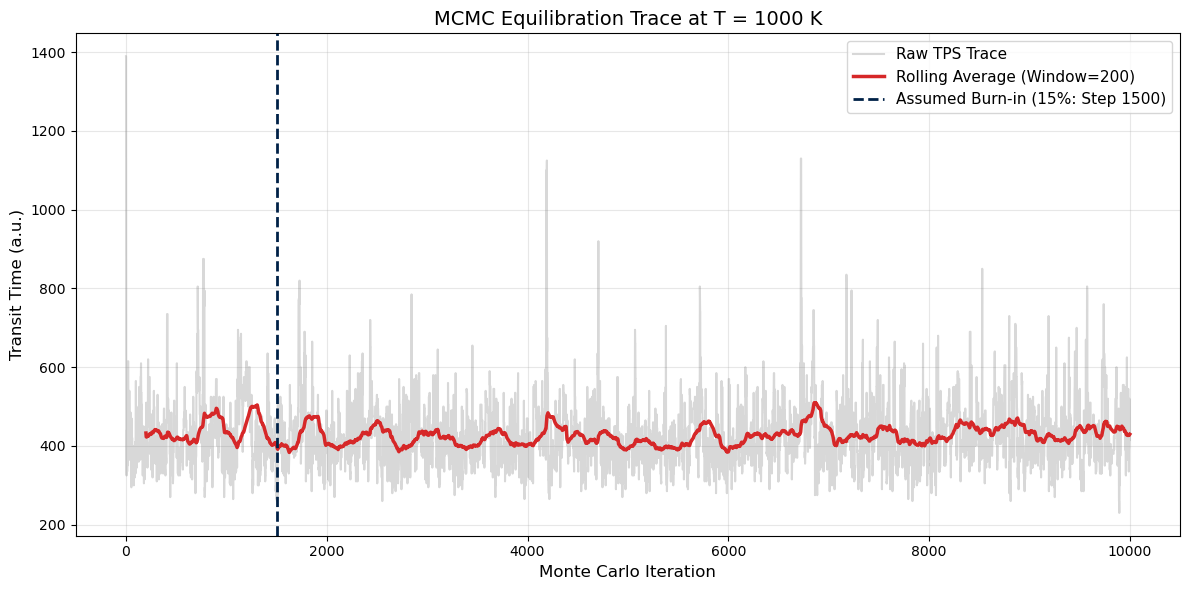

In [13]:
# Equilibration studies: 1000K

ensemble_size = 10000
max_traj_length = 5000

tps_selector = UniformShootingSelector(temp=1000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                             max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)

engine_builder = MASHEngine
tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate = path_sampling.MC_acceptance()

def verify_equilibration(tps_ensemble, dt, temp, burn_in_fraction=0.15, window_size=200):
    """
    Plots the MCMC trace of transit times to visually verify the burn-in period.
    """
    # 1. Extract transit times for the ENTIRE chain (duplicates included)
    # Note: Using your off-by-one fixed logic!
    transit_times = []
    for traj in tps_ensemble:
        grid_snaps = [s for s in traj if s.is_grid]
        transit_times.append((len(grid_snaps) - 1) * dt)
        
    transit_times = np.array(transit_times)
    iterations = np.arange(len(transit_times))
    
    # 2. Calculate a rolling average to smooth out the MCMC noise
    # We use valid mode to avoid edge artifacts
    kernel = np.ones(window_size) / window_size
    rolling_mean = np.convolve(transit_times, kernel, mode='valid')
    rolling_iters = iterations[window_size - 1:]

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    
    # Raw trace (light color)
    plt.plot(iterations, transit_times, color='gray', alpha=0.3, label='Raw TPS Trace')
    
    # Smoothed trace (bold)
    plt.plot(rolling_iters, rolling_mean, color='#d62728', linewidth=2.5, 
             label=f'Rolling Average (Window={window_size})')
    
    # Mark the assumed burn-in cutoff
    assumed_burn_in = int(len(tps_ensemble) * burn_in_fraction)
    plt.axvline(x=assumed_burn_in, color='#002147', linestyle='--', linewidth=2, 
                label=f'Assumed Burn-in (15%: Step {assumed_burn_in})')
    
    # Aesthetics
    plt.title(f"MCMC Equilibration Trace at T = {temp} K", fontsize=14)
    plt.xlabel("Monte Carlo Iteration", fontsize=12)
    plt.ylabel("Transit Time (a.u.)", fontsize=12)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

verify_equilibration(tps_ensemble=tps_ensemble, dt=dt, temp=1000)